# Sampling, Data Selection and ML Model – Fraud Detection Dataset
**Dataset:** `Fraud_Detection_Dataset.csv` (place it in the same folder as this notebook)  
**Target column:** `Fraudulent` (1 = fraud, 0 = genuine)  
**Grouping column used for sampling:** `Location` (the city of the transaction – used in place of `Country`)

**Contents**
1. Setup and loading data
2. Partition
3. Sampling – random, stratified, cluster (Tasks 1–4)
4. Data selection – missing values, identical values, correlation, chi-square
5. Split
6. Task 5 – ML model and result analysis

In [1]:
# Install only if the library is missing (works locally and on Colab)
try:
    import imblearn
except ImportError:
    %pip install imbalanced-learn

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from collections import Counter
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
SEED = 42

## 1. Load data

In [3]:
df = pd.read_csv("Fraud_Detection_Dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (51000, 12)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [4]:
print(list(df.columns))
df.info()

['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']
<class 'pandas.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  str    
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  str    
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  str    
 6   Location                          48453 non-null  str    
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                

# Partition
A 70 % partition of the data is taken (fixed `random_state` so it is reproducible).

In [5]:
split_fraction = 0.70
partition = df.sample(frac=split_fraction, random_state=SEED)
len(partition)

35700

# Random
Simple random sampling – every row has an equal chance of being picked.

In [6]:
sample_random = df.sample(n=100, random_state=SEED)
sample_random.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
4207,T4208,2440,1914.57,Online Purchase,21.0,Mobile,Seattle,1,40,12,Debit Card,0
6583,T6584,4693,2987.32,POS Payment,8.0,Desktop,Boston,2,85,13,Credit Card,0
13538,T13539,3457,1338.51,Bill Payment,14.0,Desktop,Boston,3,92,10,Credit Card,0
38447,T38448,1111,3142.30,ATM Withdrawal,NaN,Desktop,Seattle,4,47,9,Credit Card,0
22267,T22268,3178,NaN,POS Payment,16.0,Mobile,Los Angeles,3,61,14,Debit Card,0


# Stratified
The data is divided into strata (one per `Location`) and 10 % is drawn from each stratum, so every location is represented in proportion to its size.

In [7]:
sample_stratified = df.groupby("Location").sample(frac=0.1, random_state=SEED)
sample_stratified.head()
print(sample_stratified["Location"].value_counts())

Location
Boston           615
New York         611
Seattle          610
Chicago          607
Houston          603
Los Angeles      601
Miami            599
San Francisco    598
Name: count, dtype: int64


In [8]:
# NOTE: rows with a missing Location (NaN) are ignored by groupby, so they are not part of any stratum.
print("Rows with missing Location:", df["Location"].isna().sum())
print("Stratified sample size:", len(sample_stratified))

Rows with missing Location: 2547
Stratified sample size: 4844


### Task 1: Fix Number of Sample (500 only)
Both a random and a (proportional) stratified sample of **exactly 500** rows are drawn.  
For the stratified version, each location gets `500 × (its share of the data)` rows; the rounding leftovers are given to the largest locations so the total is exactly 500.

In [9]:
N = 500

# (a) Simple random sample of exactly 500
task1_random = df.sample(n=N, random_state=SEED)

# (b) Proportional stratified sample of exactly 500
known = df.dropna(subset=["Location"])
share = known["Location"].value_counts(normalize=True) * N
alloc = share.astype(int).rename("rows")           # floor
leftover = N - alloc.sum()
alloc[share.sub(alloc).sort_values(ascending=False).index[:leftover]] += 1   # give remainder to biggest fractions

task1_stratified = pd.concat([
    known[known["Location"] == loc].sample(n=int(k), random_state=SEED)
    for loc, k in alloc.items()
])

print("Random sample size    :", len(task1_random))
print("Stratified sample size:", len(task1_stratified))
print("\nAllocation per location (stratified):")
print(alloc)

Random sample size    : 500
Stratified sample size: 500

Allocation per location (stratified):
Location
Boston           63
New York         63
Seattle          63
Chicago          63
Houston          62
Los Angeles      62
Miami            62
San Francisco    62
Name: rows, dtype: int64


In [10]:
# Check the fraud rate is kept reasonably similar to the full data
print("Fraud rate - full data       :", round(df["Fraudulent"].mean(), 4))
print("Fraud rate - random 500      :", round(task1_random["Fraudulent"].mean(), 4))
print("Fraud rate - stratified 500  :", round(task1_stratified["Fraudulent"].mean(), 4))

Fraud rate - full data       : 0.0492
Fraud rate - random 500      : 0.036
Fraud rate - stratified 500  : 0.042


### Task 2: Location-wise list / count

In [11]:
# Location-wise count in the full data
loc_count = df["Location"].value_counts(dropna=False).rename_axis("Location").reset_index(name="Count")
loc_count

,Location,Count
0,Boston,6149
1,New York,6110
2,Seattle,6104
3,Chicago,6071
4,Houston,6031
5,Los Angeles,6012
6,Miami,5991
7,San Francisco,5985
8,NaN,2547


In [12]:
# Location-wise count in the three samples, side by side
compare = pd.DataFrame({
    "Full data"          : df["Location"].value_counts(),
    "Random 500"         : task1_random["Location"].value_counts(),
    "Stratified 500"     : task1_stratified["Location"].value_counts(),
}).fillna(0).astype(int)
compare.loc["Total"] = compare.sum()
compare

,Full data,Random 500,Stratified 500
Location,,,
Boston,6149,67,63
Chicago,6071,60,63
Houston,6031,56,62
Los Angeles,6012,60,62
Miami,5991,65,62
New York,6110,56,63
San Francisco,5985,59,62
Seattle,6104,55,63
Total,48453,478,500


In [13]:
# Location-wise list of unique transaction IDs (first 5 per location shown)
loc_list = df.dropna(subset=["Location"]).groupby("Location")["Transaction_ID"].apply(lambda s: list(s.head(5)))
loc_list

Location
Boston                [T6, T7, T8, T13, T19]
Chicago             [T4, T10, T14, T57, T59]
Houston            [T11, T16, T32, T36, T42]
Los Angeles        [T29, T30, T51, T61, T63]
Miami              [T17, T18, T22, T23, T26]
New York            [T2, T21, T27, T31, T33]
San Francisco         [T1, T5, T9, T12, T15]
Seattle          [T39, T64, T68, T128, T135]
Name: Transaction_ID, dtype: object

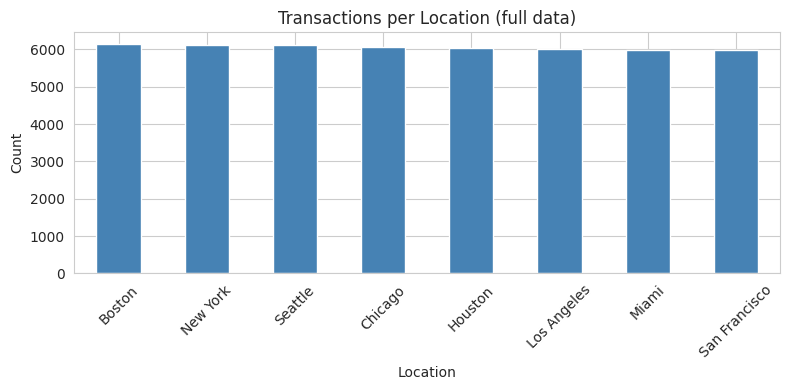

In [14]:
ax = loc_count.dropna().plot(kind="bar", x="Location", y="Count", legend=False, figsize=(8,4), color="steelblue")
ax.set_title("Transactions per Location (full data)")
ax.set_ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Task 3: Equalize the location-wise count
Every location is given the **same number of rows** (500 ÷ 8 locations = 62.5, so 4 locations get 63 and 4 get 62 → exactly 500).

In [15]:
locations = sorted(known["Location"].unique())
base, extra = divmod(N, len(locations))
equal_alloc = {loc: base + (1 if i < extra else 0) for i, loc in enumerate(locations)}

task3_equal = pd.concat([
    known[known["Location"] == loc].sample(n=k, random_state=SEED)
    for loc, k in equal_alloc.items()
])
print("Total rows:", len(task3_equal))
print(task3_equal["Location"].value_counts().sort_index())

Total rows: 500
Location
Boston           63
Chicago          63
Houston          63
Los Angeles      63
Miami            62
New York         62
San Francisco    62
Seattle          62
Name: count, dtype: int64


In [16]:
# Alternative: perfectly equal counts (same n for every location, e.g. 60 each = 480 rows)
n_each = 60
task3_equal_exact = known.groupby("Location").sample(n=n_each, random_state=SEED)
print(task3_equal_exact["Location"].value_counts().sort_index())

Location
Boston           60
Chicago          60
Houston          60
Los Angeles      60
Miami            60
New York         60
San Francisco    60
Seattle          60
Name: count, dtype: int64


# Cluster
Cluster sampling – whole groups (clusters) are randomly chosen and **all** rows of the chosen clusters are kept. Here each `Location` is a cluster.

In [17]:
locations_all = df["Location"].dropna().unique()
selected_locations = pd.Series(locations_all).sample(n=2, random_state=SEED)
print("Selected clusters:", list(selected_locations))
sample_cluster = df[df["Location"].isin(selected_locations)]
print("Cluster sample size:", len(sample_cluster))
sample_cluster.head(36)

Selected clusters: ['New York', 'Miami']
Cluster sample size: 12101


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
16,T17,4171,3960.52,Bank Transfer,13.0,Tablet,Miami,2,68,8,Debit Card,0
17,T18,3919,2327.71,Online Purchase,20.0,NaN,Miami,4,21,1,Debit Card,0
20,T21,2685,973.51,Bill Payment,2.0,Mobile,New York,1,43,12,UPI,0
21,T22,4380,2553.98,ATM Withdrawal,3.0,Mobile,Miami,1,7,9,Net Banking,0
22,T23,1769,2222.86,POS Payment,14.0,Mobile,Miami,1,103,10,UPI,0
25,T26,4485,NaN,Online Purchase,17.0,Mobile,Miami,2,63,8,UPI,0
26,T27,3853,4065.44,Online Purchase,21.0,Tablet,New York,4,99,9,Net Banking,0
30,T31,3324,428.39,POS Payment,20.0,Desktop,New York,0,85,10,Credit Card,0
32,T33,1459,2212.25,Online Purchase,10.0,Desktop,New York,4,14,13,UPI,0


In [18]:
print(sample_cluster["Location"].value_counts())

Location
New York    6110
Miami       5991
Name: count, dtype: int64


### Task 4: Sample from the 5 most / least listed locations
The 5 locations with the **most** records and the 5 with the **least** records are identified; a sample is then drawn from each group.  
(There are only 8 locations in the data, so the "top 5" and "bottom 5" groups overlap on 2 locations – that is expected.)

In [19]:
counts = df["Location"].value_counts()
top5 = counts.head(5)
bottom5 = counts.tail(5)

print("5 MOST listed locations:\n", top5, "\n")
print("5 LEAST listed locations:\n", bottom5)

5 MOST listed locations:
 Location
Boston      6149
New York    6110
Seattle     6104
Chicago     6071
Houston     6031
Name: count, dtype: int64 

5 LEAST listed locations:
 Location
Chicago          6071
Houston          6031
Los Angeles      6012
Miami            5991
San Francisco    5985
Name: count, dtype: int64


In [20]:
# Sample 100 rows from the 5 most listed locations and 100 from the 5 least listed
top5_sample    = df[df["Location"].isin(top5.index)].sample(n=100, random_state=SEED)
bottom5_sample = df[df["Location"].isin(bottom5.index)].sample(n=100, random_state=SEED)

print("Most listed - sample counts:\n", top5_sample["Location"].value_counts(), "\n")
print("Least listed - sample counts:\n", bottom5_sample["Location"].value_counts())

Most listed - sample counts:
 Location
Seattle     23
Chicago     22
Boston      22
Houston     18
New York    15
Name: count, dtype: int64 

Least listed - sample counts:
 Location
San Francisco    25
Chicago          25
Los Angeles      22
Miami            21
Houston           7
Name: count, dtype: int64


In [21]:
# Cluster version: take ALL rows of the 5 most / 5 least listed locations
cluster_top5    = df[df["Location"].isin(top5.index)]
cluster_bottom5 = df[df["Location"].isin(bottom5.index)]
print("All rows from 5 most listed locations :", len(cluster_top5))
print("All rows from 5 least listed locations:", len(cluster_bottom5))

All rows from 5 most listed locations : 30465
All rows from 5 least listed locations: 30090


# Data Selection
Four checks are used to decide which columns / rows to keep:
1. Missing values
2. Identical values (constant columns and duplicate rows)
3. Correlation analysis
4. Chi-square test

### 1. Missing values

In [22]:
missing = pd.DataFrame({
    "Missing": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
}).sort_values("Missing", ascending=False)
missing

,Missing,Missing %
Time_of_Transaction,2552,5.00
Location,2547,4.99
Transaction_Amount,2520,4.94
Device_Used,2473,4.85
Payment_Method,2469,4.84
Transaction_Type,0,0.00
Transaction_ID,0,0.00
User_ID,0,0.00
Previous_Fraudulent_Transactions,0,0.00
Account_Age,0,0.00


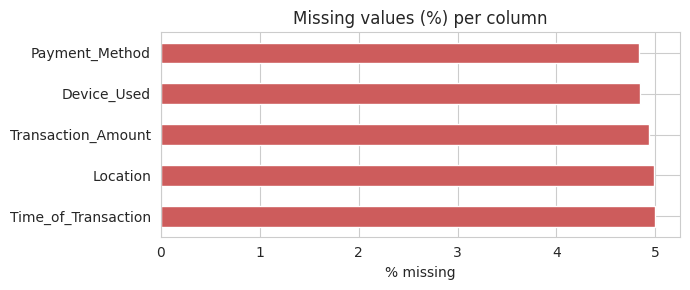

In [23]:
missing[missing["Missing"] > 0]["Missing %"].plot(kind="barh", figsize=(7,3), color="indianred")
plt.title("Missing values (%) per column")
plt.xlabel("% missing")
plt.tight_layout()
plt.show()

Five columns (`Transaction_Amount`, `Time_of_Transaction`, `Device_Used`, `Location`, `Payment_Method`) each have about 5 % missing values. That is small enough that **rows are not dropped**; instead the values are imputed later inside the ML pipeline (median for numbers, most frequent for categories).  
The data also has placeholder values `Unknown Device` (Device_Used) and `Invalid Method` (Payment_Method); they are treated as ordinary categories.

### 2. Identical values

In [24]:
# (a) Columns that hold only one value (no information)
nunique = df.nunique()
print("Constant columns:", list(nunique[nunique <= 1].index))
print()
print(nunique.sort_values())

Constant columns: []

Fraudulent                              2
Device_Used                             4
Previous_Fraudulent_Transactions        5
Transaction_Type                        5
Payment_Method                          5
Location                                8
Number_of_Transactions_Last_24H        14
Time_of_Transaction                    24
Account_Age                           119
User_ID                              4000
Transaction_Amount                  44821
Transaction_ID                      50000
dtype: int64


In [25]:
# (b) Duplicate rows / duplicate IDs
print("Fully identical rows      :", df.duplicated().sum())
print("Duplicate Transaction_IDs :", df["Transaction_ID"].duplicated().sum())

df_clean = df.drop_duplicates().copy()
print("\nRows before:", len(df), "| after removing identical rows:", len(df_clean))

Fully identical rows      : 881
Duplicate Transaction_IDs : 1000



Rows before: 51000 | after removing identical rows: 50119


In [26]:
# (c) Remaining duplicate IDs have the same ID but different values (conflicting records) - keep the first
print("Duplicate IDs still left:", df_clean["Transaction_ID"].duplicated().sum())
df_clean = df_clean.drop_duplicates(subset="Transaction_ID", keep="first").reset_index(drop=True)
print("Final rows:", len(df_clean))

Duplicate IDs still left: 119
Final rows: 50000


- No column is constant, so none is dropped for that reason.  
- The data contained repeated transactions; they are removed so the same record cannot end up in both the train and test sets (which would inflate the results).  
- `Transaction_ID` is a unique identifier and `User_ID` is just a label, so neither carries predictive meaning and both are excluded from the model.

### 3. Correlation analysis

In [27]:
corr = df_clean.corr(numeric_only=True)

print(corr["Fraudulent"].drop("Fraudulent").sort_values())

Number_of_Transactions_Last_24H    -0.003891
Previous_Fraudulent_Transactions    0.000634
Transaction_Amount                  0.004995
Account_Age                         0.005704
Time_of_Transaction                 0.005998
User_ID                             0.007373
Name: Fraudulent, dtype: float64


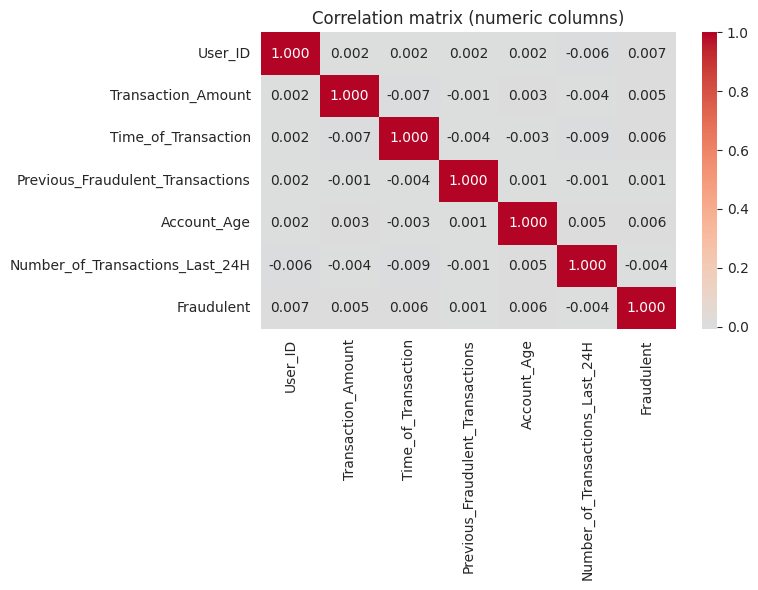

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (numeric columns)")
plt.tight_layout()
plt.show()

All correlations with `Fraudulent` are very close to 0 (|r| < 0.01), and the numeric features are also uncorrelated with each other, so there is no multicollinearity to remove. None of the numeric columns has a strong *linear* relationship with fraud.

### 4. Chi-square test

In [29]:
from sklearn.feature_selection import chi2, SelectKBest
from scipy.stats import chi2_contingency

X = df_clean.drop(columns=["Fraudulent", "Transaction_ID", "User_ID"])
Y = df_clean["Fraudulent"]

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()
print("Numeric:", num_cols)
print("Categorical:", cat_cols)

Numeric: ['Transaction_Amount', 'Time_of_Transaction', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H']
Categorical: ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']


In [30]:
# (a) Chi-square score with SelectKBest. chi2 needs non-negative, non-missing numbers,
#     so: impute -> encode categories -> min-max scale.
prep_chi = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("mm", MinMaxScaler())]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("ord", OrdinalEncoder()), ("mm", MinMaxScaler())]), cat_cols),
])
X_chi = prep_chi.fit_transform(X)

selector = SelectKBest(score_func=chi2, k="all")
selector.fit(X_chi, Y)

chi_scores = pd.DataFrame({"Feature": num_cols + cat_cols,
                           "Chi2 score": selector.scores_,
                           "p-value": selector.pvalues_}).sort_values("Chi2 score", ascending=False)
chi_scores

,Feature,Chi2 score,p-value
7,Location,0.814719,0.366729
5,Transaction_Type,0.500960,0.479079
6,Device_Used,0.354852,0.551379
1,Time_of_Transaction,0.298404,0.584884
3,Account_Age,0.276370,0.599091
0,Transaction_Amount,0.192766,0.660625
4,Number_of_Transactions_Last_24H,0.144835,0.703521
2,Previous_Fraudulent_Transactions,0.005046,0.943370
8,Payment_Method,0.003493,0.952869


In [31]:
# (b) Chi-square test of independence for each categorical column vs Fraudulent
rows = []
for c in cat_cols + ["Previous_Fraudulent_Transactions"]:
    table = pd.crosstab(df_clean[c], df_clean["Fraudulent"])
    stat, p, dof, _ = chi2_contingency(table)
    rows.append([c, round(stat, 3), dof, round(p, 4), "Dependent" if p < 0.05 else "Independent"])

pd.DataFrame(rows, columns=["Column", "Chi2", "dof", "p-value", "Result (alpha=0.05)"])

,Column,Chi2,dof,p-value,Result (alpha=0.05)
0,Transaction_Type,2.553,4,0.6351,Independent
1,Device_Used,4.858,3,0.1825,Independent
2,Location,11.279,7,0.1269,Independent
3,Payment_Method,0.822,4,0.9355,Independent
4,Previous_Fraudulent_Transactions,2.240,4,0.6918,Independent


**Reading the result:** a column is considered related to fraud only if its p-value is below 0.05. Columns with p ≥ 0.05 are statistically independent of `Fraudulent`.  
Overall the data selection steps show that **no single feature is strongly associated with fraud**, so all remaining feature columns are kept for modelling and the model is allowed to look for combinations, while the identifier columns (`Transaction_ID`, `User_ID`) are dropped.

In [32]:
X = df_clean.drop(columns=["Fraudulent", "Transaction_ID", "User_ID"])
Y = df_clean["Fraudulent"]
print(X.shape, Y.shape)
Y.value_counts()

(50000, 9) (50000,)


Fraudulent
0    47540
1     2460
Name: count, dtype: int64

# Split
Stratified 80/20 train-test split, so both parts keep the same (small) fraud proportion.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.20, random_state=SEED, stratify=Y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Fraud share  train:", round(y_train.mean(), 4), "| test:", round(y_test.mean(), 4))
print("Class counts in train:", Counter(y_train))

Train: (40000, 9) | Test: (10000, 9)
Fraud share  train: 0.0492 | test: 0.0492
Class counts in train: Counter({0: 38032, 1: 1968})


# Task 5: ML Model
**Problem:** only about 5 % of transactions are fraud (heavily imbalanced), so plain accuracy is misleading – a model that predicts "not fraud" every time is ~95 % accurate. The imbalance is handled with **SMOTE** (oversampling applied to the *training data only*) and models are judged on precision, recall, F1 and ROC-AUC.

Pipeline: impute missing values → scale numbers / one-hot encode categories → SMOTE → classifier.

In [34]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, roc_curve)

preprocess = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=20,
                                            n_jobs=-1, random_state=SEED),
}

fitted, results = {}, []
for name, clf in models.items():
    pipe = ImbPipeline([("prep", preprocess), ("smote", SMOTE(random_state=SEED)), ("clf", clf)])
    pipe.fit(X_train, y_train)
    pred  = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    fitted[name] = (pipe, pred, proba)
    results.append([name, accuracy_score(y_test, pred), precision_score(y_test, pred, zero_division=0),
                    recall_score(y_test, pred), f1_score(y_test, pred), roc_auc_score(y_test, proba)])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]).round(4)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.4801,0.0475,0.5020,0.0868,0.4960
1,Random Forest,0.8686,0.0484,0.0894,0.0628,0.4985


## Result Analysis

In [35]:
# Baseline: always predict 'not fraud'
base_pred = np.zeros(len(y_test), dtype=int)
print("Baseline accuracy (always 'not fraud'):", round(accuracy_score(y_test, base_pred), 4))
print("Baseline recall for fraud             :", recall_score(y_test, base_pred))

Baseline accuracy (always 'not fraud'): 0.9508
Baseline recall for fraud             : 0.0


In [36]:
for name, (pipe, pred, proba) in fitted.items():
    print("=" * 60); print(name); print("=" * 60)
    print(classification_report(y_test, pred, target_names=["Genuine", "Fraud"], zero_division=0))

Logistic Regression
              precision    recall  f1-score   support

     Genuine       0.95      0.48      0.64      9508
       Fraud       0.05      0.50      0.09       492

    accuracy                           0.48     10000
   macro avg       0.50      0.49      0.36     10000
weighted avg       0.90      0.48      0.61     10000

Random Forest
              precision    recall  f1-score   support

     Genuine       0.95      0.91      0.93      9508
       Fraud       0.05      0.09      0.06       492

    accuracy                           0.87     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.91      0.87      0.89     10000



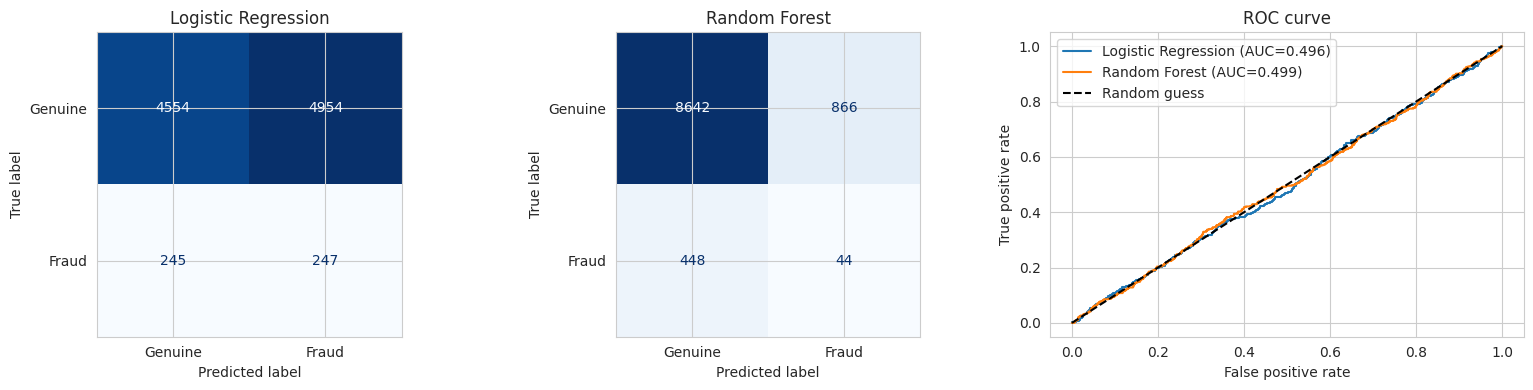

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, (pipe, pred, proba)) in zip(axes[:2], fitted.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["Genuine", "Fraud"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
for name, (pipe, pred, proba) in fitted.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[2].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
axes[2].plot([0, 1], [0, 1], "k--", label="Random guess")
axes[2].set_xlabel("False positive rate"); axes[2].set_ylabel("True positive rate")
axes[2].set_title("ROC curve"); axes[2].legend()
plt.tight_layout(); plt.show()

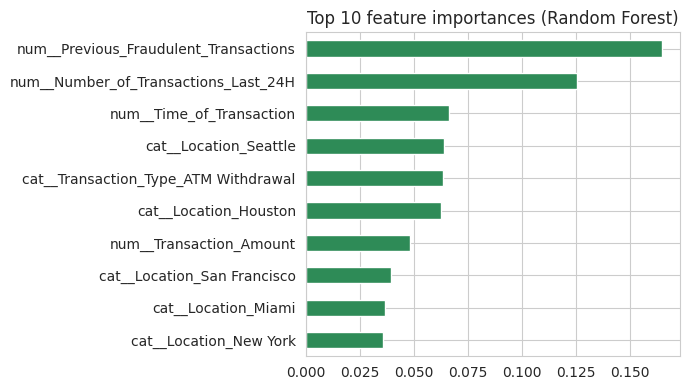

In [38]:
# Feature importance from the random forest
rf_pipe = fitted["Random Forest"][0]
names = rf_pipe.named_steps["prep"].get_feature_names_out()
imp = pd.Series(rf_pipe.named_steps["clf"].feature_importances_, index=names).sort_values(ascending=False).head(10)
imp.sort_values().plot(kind="barh", figsize=(7,4), color="seagreen")
plt.title("Top 10 feature importances (Random Forest)")
plt.tight_layout(); plt.show()

### Conclusions
**Sampling**
- Random, stratified (proportional), equal-count and cluster samples were created, and a fixed sample of 500 was produced as required. The 8 locations are almost equally represented in the data, so proportional and equal allocation give very similar results.

**Data selection**
- About 5 % of values are missing in five columns; they are imputed rather than dropped.
- Repeated transactions were found and removed to avoid train/test leakage. No constant columns exist.
- Correlation and chi-square tests show **no feature has a meaningful relationship with `Fraudulent`**.

**Model**
- The dataset is highly imbalanced (~5 % fraud). A model that always says "genuine" scores ~95 % accuracy but catches no fraud, so accuracy alone is not a valid measure.
- Both models perform at chance level. ROC-AUC is about 0.50 for each, and fraud precision (about 0.05) simply equals the base fraud rate. Logistic Regression flags many transactions (recall about 0.50) but at an accuracy of about 48 %, well below the 95 % baseline. Random Forest keeps accuracy high but catches only about 9 % of fraud, which is what random guessing would give.
- This is consistent with the data-selection findings: the available features carry almost no signal about fraud, so no model can do much better with this data.

**Recommendations**
- Add more informative features (e.g. spending pattern vs the user's history, time since last transaction, merchant category, geo-distance from usual location).
- Optimise the decision threshold for the business cost of missed fraud vs false alarms, and consider cost-sensitive learning or anomaly-detection methods.